# Step Evenness Score — unsupervised (0–100)

Assigns each step an **evenness score from 0 (very uneven/rough) to 100 (very even/smooth)** with
**no surface labels** anywhere. It combines a set of per-step *irregularity* features — foot-tilt
range, centre-of-pressure wander, pressure jitter, gyro wobble, and step-to-step consistency —
into one index, calibrated so 50 = a typical step.

This is a *scoring model*, not a classifier: it fits a robust scaler on your recordings, then can
score any new step. It never sees a surface tag. (Section 7 optionally checks the score against
surface tags **only to validate** it — labels are never used to build the score.)

In [1]:
import os, glob, json, numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import norm

# ---- paths ----
# Recordings to FIT the evenness scale on. Set this to wherever your recordings live.
# Relative paths resolve from the notebook's working directory (print(os.getcwd()) to check).
# For certainty, use an absolute path, e.g.:
#   RAW_GLOB = r'C:\\Users\\Sam\\WalkSensePlace\\Individual Users\\**\\*.csv'
REPO_ROOT = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(REPO_ROOT, 'Individual Users')): break
    _up = os.path.dirname(REPO_ROOT)
    if _up == REPO_ROOT: break
    REPO_ROOT = _up
print('REPO_ROOT =', REPO_ROOT)
RAW_GLOB   = os.path.join(REPO_ROOT, 'Individual Users', '**', '*.csv')
CHARTS_DIR = os.path.join(REPO_ROOT, 'Charts_Graphs'); os.makedirs(CHARTS_DIR, exist_ok=True)

# ---- signal / layout ----
FS = 62.5; MIN_DP, MAX_DP = 15, 150
ALL_SENSORS = [f'pressure_{i:02d}' for i in range(1, 13)]
BASE_COLS   = set(['sole_id','timestamp','accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z',
                   'magn_x','magn_y','magn_z','corrupt'] + ALL_SENSORS)

# ---- evenness feature set (every one: higher = MORE uneven) ----
WITHIN_STEP = ['orient_range_a','orient_range_b','cop_wander','press_jitter','gyro_std']
STEP_TO_STEP = ['stance_dur','loading_rate','impact','tiltA','tiltB']    # -> rolling 3-step std
EVENNESS_FEATURES = WITHIN_STEP + [f'{c}_roll3_std' for c in STEP_TO_STEP]
print('evenness features:', EVENNESS_FEATURES)
SURF_COLORS = {'grass':'#4CAF50','loose':'#8D6E63','paved':'#607D8B','soft':'#4CAF50','hard':'#607D8B'}

REPO_ROOT = c:\Users\Sam\WalkSensePlace
evenness features: ['orient_range_a', 'orient_range_b', 'cop_wander', 'press_jitter', 'gyro_std', 'stance_dur_roll3_std', 'loading_rate_roll3_std', 'impact_roll3_std', 'tiltA_roll3_std', 'tiltB_roll3_std']


## 1. Per-step irregularity extractor (label-free)

Detects steps from total-pressure peaks and computes each irregularity feature per step. No surface markers are read.

In [2]:
def find_steps(tot):
    mx = np.nanmax(tot) if np.nanmax(tot) > 0 else 1.0
    pk, _ = find_peaks(tot, distance=25, prominence=mx*0.15); return pk

def extract_steps(df, rec, foot):
    """Per-step irregularity features for one sole's dataframe. Returns a DataFrame."""
    df = df.reset_index(drop=True)
    if len(df) < MIN_DP: return pd.DataFrame()
    P   = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).values
    tot = P.sum(1)
    ax = pd.to_numeric(df['accel_x'],errors='coerce').fillna(0).values
    ay = pd.to_numeric(df['accel_y'],errors='coerce').fillna(0).values
    az = pd.to_numeric(df['accel_z'],errors='coerce').fillna(0).values
    G  = df[['gyro_x','gyro_y','gyro_z']].apply(pd.to_numeric,errors='coerce').fillna(0).values
    Gc = G - np.median(G, 0)
    amag = np.sqrt(ax**2+ay**2+az**2); gmag = np.sqrt((Gc**2).sum(1))
    tA = np.degrees(np.arctan2(ax, np.hypot(ay, az)))
    tB = np.degrees(np.arctan2(az, np.hypot(ax, ay)))
    ts = pd.to_numeric(df['timestamp'], errors='coerce').values if 'timestamp' in df.columns else np.arange(len(df))
    pk = find_steps(tot); recs = []; order = 0
    for i in range(len(pk)-1):
        a, b = pk[i], pk[i+1]; n = b-a
        if n < MIN_DP or n > MAX_DP: continue
        Pw = P[a:b]; totw = tot[a:b]; sc = totw.mean()+1e-9; wam = amag[a:b]; wgm = gmag[a:b]
        Qn = Pw/(Pw.sum(1, keepdims=True)+1e-9); t = int(np.argmin(wgm))
        recs.append(dict(
            rec=rec, foot=foot, order=order, t_ms=float(ts[(a+b)//2]),
            orient_range_a = float(tA[a:b].max()-tA[a:b].min()),
            orient_range_b = float(tB[a:b].max()-tB[a:b].min()),
            cop_wander     = float(np.mean(np.abs(np.diff(Qn, axis=0)).sum(1))) if n > 1 else 0.0,
            press_jitter   = float(np.mean(np.std(np.diff(Pw, n=2, axis=0), axis=0))/sc) if n > 2 else 0.0,
            gyro_std       = float(np.mean([np.std(Gc[a:b, k]) for k in range(3)])),
            stance_dur   = float((totw > 0.5*sc).mean()),
            loading_rate = float(np.max(np.diff(totw))/sc),
            impact       = float(wam[:max(1, n//3)].max()/(np.median(wam)+1e-9)),
            tiltA = float(tA[a:b][t]), tiltB = float(tB[a:b][t])))
        order += 1
    return pd.DataFrame(recs)
print('extractor defined')

extractor defined


## 2. Build steps from the recordings

Every step from every recording — no labels required. Then add the step-to-step consistency features (rolling 3-step std within each recording+foot).

In [3]:
files = sorted(glob.glob(RAW_GLOB, recursive=True))
print(f'cwd = {os.getcwd()}')
print(f'RAW_GLOB = {RAW_GLOB!r}  ->  {len(files)} file(s) matched')
if not files:
    files = sorted(glob.glob(os.path.join('**','REC_*.csv'), recursive=True))
    print(f'fallback search for REC_*.csv -> {len(files)} file(s)')
if not files:
    raise FileNotFoundError(
        f"No CSVs found. RAW_GLOB={RAW_GLOB!r} matched nothing from cwd {os.getcwd()!r}. "
        r"Set RAW_GLOB in the config cell to your recordings, e.g. "
        r"r'C:\\Users\\Sam\\WalkSensePlace\\Individual Users\\**\\*.csv'")

parts = []
for f in files:
    try: raw = pd.read_csv(f, low_memory=False)
    except Exception: continue
    if 'sole_id' not in raw.columns: continue
    rec = os.path.basename(f)
    soles = list(raw['sole_id'].dropna().unique())
    pairs = [(s, ('right' if str(s) in ('1','1.0') else 'left' if str(s) in ('2','2.0') else f'sole{s}')) for s in soles]
    for sole, foot in (pairs or [(1,'right'),(2,'left')]):
        st = extract_steps(raw[raw['sole_id'] == sole], rec, foot)
        if len(st): parts.append(st)
if not parts:
    raise ValueError(f'Matched {len(files)} CSV(s) but extracted 0 steps. Check for sole_id, '
                     'pressure_01..12, accel_x/y/z, gyro_x/y/z columns and enough samples per step.')

steps = pd.concat(parts, ignore_index=True).sort_values(['rec','foot','order']).reset_index(drop=True)
for c in STEP_TO_STEP:
    steps[f'{c}_roll3_std'] = steps.groupby(['rec','foot'])[c].transform(
        lambda x: x.rolling(3, min_periods=1).std().fillna(0))
print(f'{len(steps)} steps from {steps.rec.nunique()} recordings')
print(steps[EVENNESS_FEATURES].describe().round(3).T[['mean','std','min','max']].to_string())

cwd = c:\Users\Sam\WalkSensePlace\notebooks
RAW_GLOB = 'c:\\Users\\Sam\\WalkSensePlace\\Individual Users\\**\\*.csv'  ->  43 file(s) matched
14907 steps from 43 recordings
                               mean         std        min          max
orient_range_a               56.627      17.550      1.757      131.077
orient_range_b               71.673       8.906      1.487      132.909
cop_wander                    0.054       0.021      0.016        0.115
press_jitter                  0.007       0.003      0.002        0.021
gyro_std                2176291.256  315111.588  44274.666  3783319.713
stance_dur_roll3_std          0.035       0.053      0.000        0.269
loading_rate_roll3_std        0.023       0.023      0.000        0.261
impact_roll3_std              0.220       0.280      0.000        1.825
tiltA_roll3_std               2.254       2.152      0.000       18.768
tiltB_roll3_std               2.073       4.038      0.000       43.949


## 3. Fit the scale and compute the 0–100 evenness score

Each feature is **robustly standardised** (median / IQR, clipped) so no single feature or outlier
dominates, then averaged into an *unevenness index* U (higher = rougher). U is standardised and
passed through the normal CDF so the score is calibrated and transferable: **50 = a typical step,
higher = smoother/more even.** The fitted numbers are saved so any new step can be scored the same way.

In [4]:
def robust_center_scale(x):
    med = float(np.median(x)); iqr = float(np.subtract(*np.percentile(x, [75, 25])))
    if iqr <= 0: iqr = float(np.std(x)) or 1.0
    return med, iqr

# fit per-feature center/scale
feat_cs = {c: robust_center_scale(steps[c].values) for c in EVENNESS_FEATURES}
def _z(col, v): m, s = feat_cs[col]; return np.clip((v - m)/(s + 1e-9), -4, 4)

Z = np.column_stack([_z(c, steps[c].values) for c in EVENNESS_FEATURES])
U = Z.mean(1)                                   # unevenness index (higher = rougher)
U_med, U_iqr = robust_center_scale(U)
steps['evenness'] = np.clip(100*norm.cdf(-(U - U_med)/(U_iqr + 1e-9)), 0, 100)

SCALER = {'features': EVENNESS_FEATURES, 'feat_center_scale': feat_cs,
          'U_center': U_med, 'U_scale': U_iqr}
json.dump(SCALER, open(os.path.join(CHARTS_DIR, 'evenness_scaler.json'), 'w'), indent=1)
steps[['rec','foot','order','t_ms','evenness']+EVENNESS_FEATURES].to_csv(
    os.path.join(CHARTS_DIR, 'evenness_scores.csv'), index=False)
print('evenness score:  mean %.1f  sd %.1f  min %.1f  max %.1f'
      % (steps.evenness.mean(), steps.evenness.std(), steps.evenness.min(), steps.evenness.max()))
print(steps.evenness.describe(percentiles=[.05,.25,.5,.75,.95]).round(1).to_string())
print('\nsaved evenness_scores.csv + evenness_scaler.json')

evenness score:  mean 48.5  sd 24.2  min 0.0  max 99.8
count    14907.0
mean        48.5
std         24.2
min          0.0
5%           5.7
25%         30.4
50%         50.0
75%         68.7
95%         84.4
max         99.8

saved evenness_scores.csv + evenness_scaler.json


## 4. Score distribution & what drives it

The spread of scores, and how strongly each feature pushes a step toward *uneven* (correlation of the feature with the unevenness index).

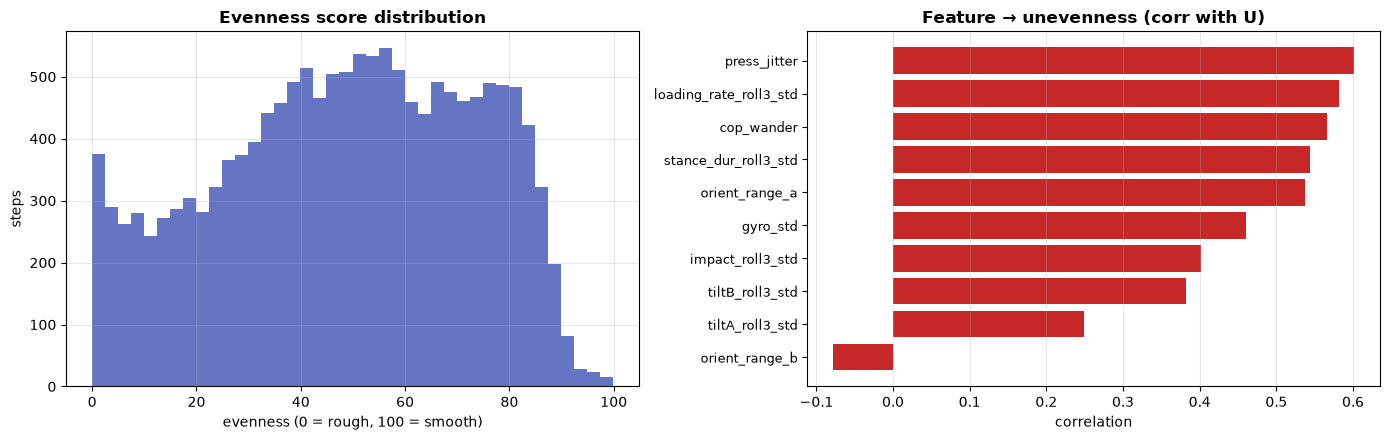

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].hist(steps['evenness'], bins=40, color='#3F51B5', alpha=.8)
ax[0].set_title('Evenness score distribution', fontweight='bold')
ax[0].set_xlabel('evenness (0 = rough, 100 = smooth)'); ax[0].set_ylabel('steps'); ax[0].grid(alpha=.3)
contrib = pd.Series({c: np.corrcoef(_z(c, steps[c].values), U)[0,1] for c in EVENNESS_FEATURES}).sort_values()
ax[1].barh(range(len(contrib)), contrib.values, color='#C62828')
ax[1].set_yticks(range(len(contrib))); ax[1].set_yticklabels(contrib.index, fontsize=9)
ax[1].set_title('Feature → unevenness (corr with U)', fontweight='bold'); ax[1].set_xlabel('correlation'); ax[1].grid(axis='x', alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'evenness_distribution.png'), dpi=140, bbox_inches='tight'); plt.show()

## 5. Evenness along a recording

How the score varies step-to-step within one recording+foot — spikes/dips mark rougher/smoother stretches.

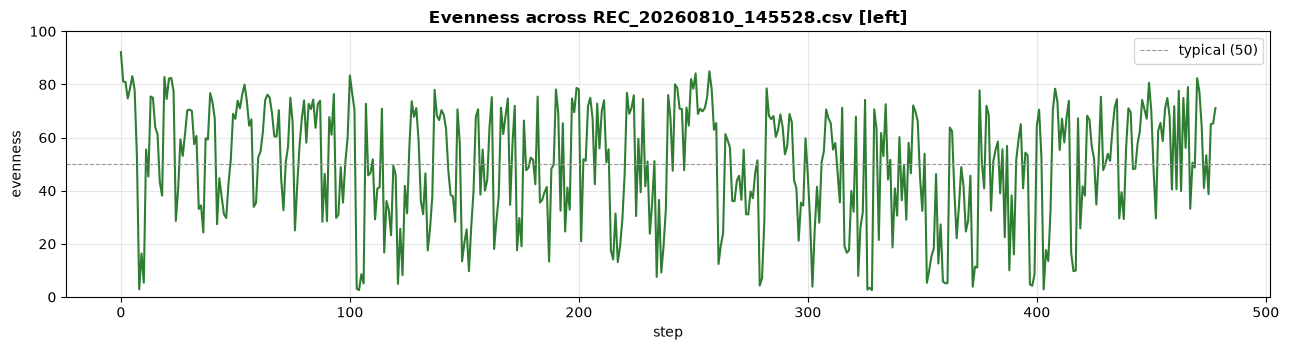

In [6]:
g = steps.groupby(['rec','foot']).size().sort_values(ascending=False)
rec0, foot0 = g.index[0]
seq = steps[(steps.rec==rec0)&(steps.foot==foot0)].sort_values('order')
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(seq['order'], seq['evenness'], color='#2E7D32', lw=1.5)
ax.axhline(50, color='#999', ls='--', lw=.8, label='typical (50)')
ax.set_title(f'Evenness across {rec0} [{foot0}]', fontweight='bold')
ax.set_xlabel('step'); ax.set_ylabel('evenness'); ax.set_ylim(0,100); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'evenness_timeseries.png'), dpi=140, bbox_inches='tight'); plt.show()

## 6. Score a new recording

Apply the fitted scaler to any recording (no labels), returning a per-step evenness score with a timestamp (so it can be joined to a GPX for mapping).

In [7]:
def score_recording(csv_path, scaler=SCALER):
    raw = pd.read_csv(csv_path, low_memory=False)
    if 'sole_id' not in raw.columns:
        raise ValueError(f"{os.path.basename(csv_path)} has no 'sole_id' column")
    soles = list(raw['sole_id'].dropna().unique())
    pairs = [(s, ('right' if str(s) in ('1','1.0') else 'left' if str(s) in ('2','2.0') else f'sole{s}')) for s in soles]
    parts = []
    for sole, foot in (pairs or [(1,'right'),(2,'left')]):
        st = extract_steps(raw[raw['sole_id'] == sole], os.path.basename(csv_path), foot)
        if len(st): parts.append(st)
    if not parts: return pd.DataFrame()
    S = pd.concat(parts, ignore_index=True).sort_values(['foot','order'])
    for c in STEP_TO_STEP:
        S[f'{c}_roll3_std'] = S.groupby('foot')[c].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))
    cs = scaler['feat_center_scale']
    Zn = np.column_stack([np.clip((S[c].values - cs[c][0])/(cs[c][1]+1e-9), -4, 4) for c in scaler['features']])
    Un = Zn.mean(1)
    S['evenness'] = np.clip(100*norm.cdf(-(Un - scaler['U_center'])/(scaler['U_scale']+1e-9)), 0, 100)
    return S[['foot','order','t_ms','evenness']]

# demo on the first recording:
_demo = sorted(glob.glob(RAW_GLOB, recursive=True))
if _demo:
    r = score_recording(_demo[0]); print(f'scored {len(r)} steps from {os.path.basename(_demo[0])}')
    print(r['evenness'].describe().round(1).to_string())

scored 155 steps from REC_0811_00000.csv
count    155.0
mean      40.5
std       23.7
min        3.3
25%       20.0
50%       37.0
75%       61.2
max       99.0


## 7. (Optional) Validation against surface tags

Sanity check only — **labels are not used to build the score.** If the recordings carry surface
markers, we expect compliant/irregular ground (grass) to score lower evenness than firm ground.

In [8]:
SMAP = {'grass':'grass','dirt':'loose','compact ground':'loose','compacted ground':'loose',
        'concrete':'paved','asphalt':'paved','exposed aggregate':'paved','brick':'paved'}
def label_rows(df):
    df = df.sort_values('timestamp').reset_index(drop=True); df['surf'] = None; ev = []
    for c in df.columns:
        if c in BASE_COLS: continue
        cls = SMAP.get(c.strip().lower())
        if cls is None: continue
        for idx in df.index[df[c].astype(str).str.strip()=='x']: ev.append((idx, cls))
    ev = sorted(ev)
    for j,(i0,l) in enumerate(ev):
        i1 = ev[j+1][0] if j+1 < len(ev) else len(df); df.loc[i0:i1-1,'surf'] = l
    return df

val = []
for f in sorted(glob.glob(RAW_GLOB, recursive=True)):
    raw = label_rows(pd.read_csv(f, low_memory=False)); rec = os.path.basename(f)
    if raw['surf'].notna().sum() == 0: continue
    for sole, foot in [(1,'right'),(2,'left')]:
        sub = raw[raw['sole_id']==sole].reset_index(drop=True)
        st = extract_steps(sub, rec, foot)
        if not len(st): continue
        # majority surface per step for validation
        P = sub[ALL_SENSORS].apply(pd.to_numeric,errors='coerce').fillna(0).values; tot = P.sum(1)
        pk = find_steps(tot); surf = sub['surf'].values; labs=[]
        k=0
        for i in range(len(pk)-1):
            a,b=pk[i],pk[i+1]
            if b-a<MIN_DP or b-a>MAX_DP: continue
            u=pd.unique(surf[a:b][pd.notna(surf[a:b])]); labs.append(u[0] if len(u)==1 else None); k+=1
        st=st.iloc[:len(labs)].copy(); st['surf']=labs; val.append(st)
if val:
    V = pd.concat(val, ignore_index=True)
    key = steps.set_index(['rec','foot','order'])['evenness']
    V['evenness'] = V.set_index(['rec','foot','order']).index.map(key)
    V = V.dropna(subset=['surf','evenness'])
    print('mean evenness by surface (validation only):')
    print(V.groupby('surf')['evenness'].agg(['mean','median','count']).round(1).to_string())
    print('\nExpect grass (compliant/irregular) lowest — confirms the score tracks compliance without labels.')
else:
    V = pd.DataFrame(columns=['surf','evenness'])
    print('No surface tags found — skipping validation (the score does not need them).')

mean evenness by surface (validation only):
       mean  median  count
surf                      
grass  41.0    39.4   3574
loose  55.2    57.3   2062
paved  49.8    51.2   8995

Expect grass (compliant/irregular) lowest — confirms the score tracks compliance without labels.


## 8. Evenness per step, coloured by surface

Every scored step as a point, jittered within its surface group and coloured by surface. (Uses the validation labels from §7 for colour only — the scores themselves were built without labels.)

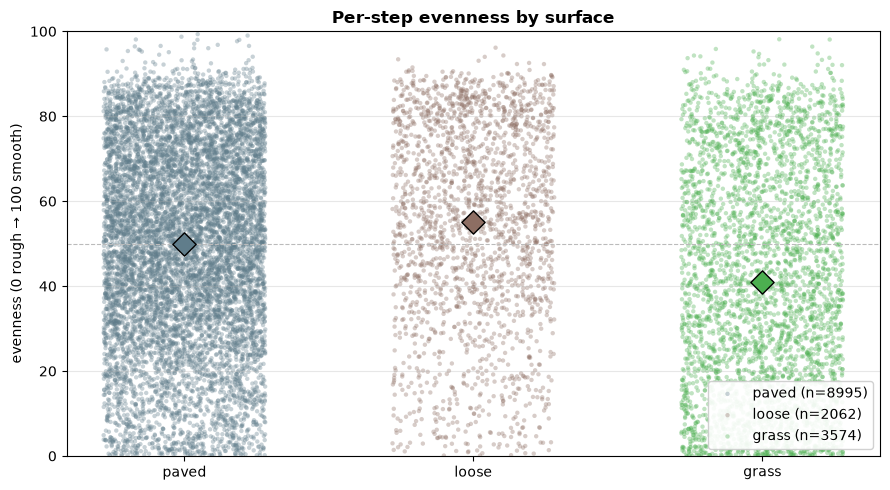

In [9]:
if len(V):
    order = [s for s in ['paved','loose','grass','soft','hard'] if s in V['surf'].unique()]
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, s in enumerate(order):
        vv = V.loc[V['surf'] == s, 'evenness'].values
        x = i + rng.uniform(-0.28, 0.28, size=len(vv))
        ax.scatter(x, vv, s=10, alpha=0.35, color=SURF_COLORS.get(s, '#888'), edgecolors='none', label=f'{s} (n={len(vv)})')
        ax.scatter([i],[vv.mean()], s=140, marker='D', color=SURF_COLORS.get(s,'#888'),
                   edgecolors='black', zorder=5)   # mean diamond
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    ax.set_ylim(0,100); ax.axhline(50, color='#bbb', ls='--', lw=.8)
    ax.set_ylabel('evenness (0 rough → 100 smooth)'); ax.set_title('Per-step evenness by surface', fontweight='bold')
    ax.legend(loc='lower right', framealpha=.9); ax.grid(axis='y', alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'evenness_points_by_surface.png'), dpi=140, bbox_inches='tight'); plt.show()
else:
    print('No surface labels available — run §7 first (needs recordings with surface tags).')

## 9. Evenness distributions by surface

Overlaid histograms (left) and violins (right) of the evenness score per surface — two views of how the classes separate.

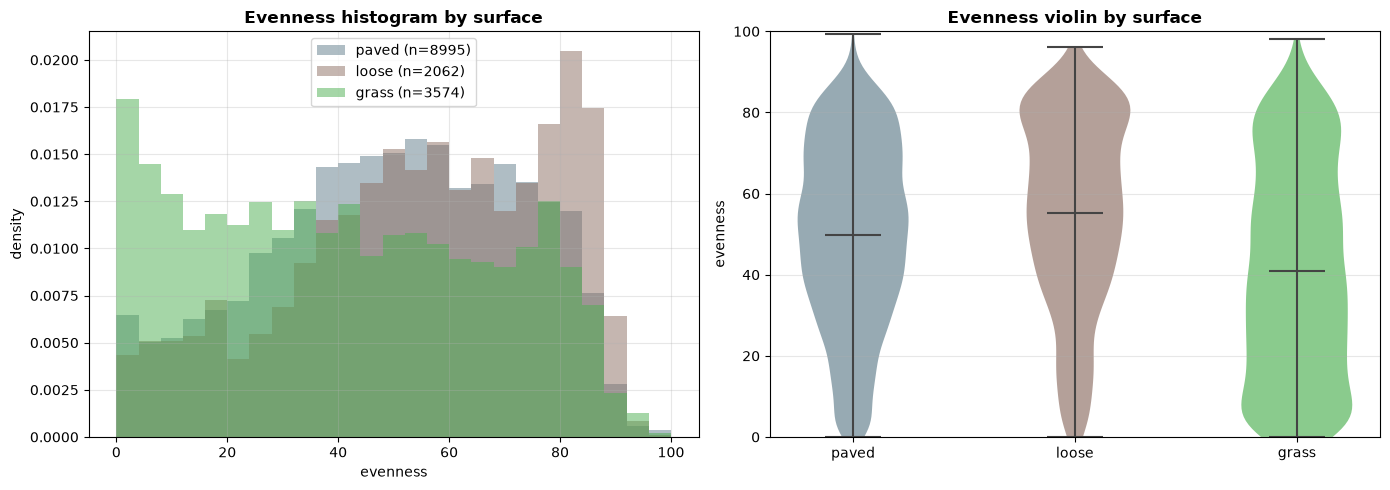

       mean  median   std  count
surf                            
grass  41.0    39.4  26.2   3574
loose  55.2    57.3  23.5   2062
paved  49.8    51.2  22.7   8995


In [10]:
if len(V):
    order = [s for s in ['paved','loose','grass','soft','hard'] if s in V['surf'].unique()]
    data = [V.loc[V['surf']==s,'evenness'].values for s in order]
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    # (a) overlaid histograms (density) per surface
    bins = np.linspace(0, 100, 26)
    for s, d in zip(order, data):
        ax[0].hist(d, bins=bins, density=True, alpha=0.5, color=SURF_COLORS.get(s,'#888'), label=f'{s} (n={len(d)})')
    ax[0].set_title('Evenness histogram by surface', fontweight='bold')
    ax[0].set_xlabel('evenness'); ax[0].set_ylabel('density'); ax[0].legend(); ax[0].grid(alpha=.3)
    # (b) violin plot per surface
    parts = ax[1].violinplot(data, showmeans=True, showextrema=True)
    for pc, s in zip(parts['bodies'], order):
        pc.set_facecolor(SURF_COLORS.get(s,'#888')); pc.set_alpha(0.65)
    for key in ('cmeans','cmaxes','cmins','cbars'):
        if key in parts: parts[key].set_color('#444')
    ax[1].set_xticks(range(1, len(order)+1)); ax[1].set_xticklabels(order)
    ax[1].set_ylim(0,100); ax[1].set_ylabel('evenness'); ax[1].set_title('Evenness violin by surface', fontweight='bold'); ax[1].grid(axis='y', alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'evenness_dist_by_surface.png'), dpi=140, bbox_inches='tight'); plt.show()
    print(V.groupby('surf')['evenness'].agg(['mean','median','std','count']).round(1).to_string())
else:
    print('No surface labels available — run §7 first (needs recordings with surface tags).')

## 10. Per-walk analysis — how even, and how variable

Scores every step of each walk with the fitted scaler, then summarises each route two ways: **how even it is overall** (mean/median evenness) and **how variable the evenness is along it** (std, IQR, coefficient of variation), plus the share of rough vs smooth steps. Set `WALKS_GLOB` to the recordings you want treated as walks.

In [11]:
# recordings to analyse as individual walks (default: the fitting set; point at GPS walks if you prefer)
WALKS_GLOB = RAW_GLOB
ROUGH_THR, SMOOTH_THR = 35, 65      # evenness below/above these = a rough / smooth step

files = sorted(glob.glob(WALKS_GLOB, recursive=True))
print(f'WALKS_GLOB = {WALKS_GLOB!r}  ->  {len(files)} file(s)')
walk_rows = []; errs = 0
for f in files:
    try:
        r = score_recording(f)
    except Exception as ex:
        if errs < 3: print(f'  [skip] {os.path.basename(f)}: {ex}')
        errs += 1; continue
    if not len(r):
        if errs < 3: print(f'  [skip] {os.path.basename(f)}: 0 steps extracted'); errs += 1
        continue
    e = r['evenness'].values; n = len(e)
    walk_rows.append(dict(
        walk=os.path.basename(f), n_steps=n,
        mean_evenness=float(np.mean(e)), median_evenness=float(np.median(e)),
        std_evenness=float(np.std(e)),                             # variability (absolute)
        iqr_evenness=float(np.subtract(*np.percentile(e,[75,25]))),
        cv_evenness=float(np.std(e)/(np.mean(e)+1e-9)),            # variability (relative)
        p10=float(np.percentile(e,10)), p90=float(np.percentile(e,90)),
        pct_rough=float(100*np.mean(e<ROUGH_THR)), pct_smooth=float(100*np.mean(e>SMOOTH_THR))))
if not walk_rows:
    raise ValueError(f'No walks scored from {len(files)} file(s) matched by WALKS_GLOB={WALKS_GLOB!r}. '
                     'Check the recordings have sole_id / pressure_01..12 / accel_* / gyro_* columns, '
                     'or point WALKS_GLOB at the right folder.')
walks = pd.DataFrame(walk_rows).sort_values('mean_evenness').reset_index(drop=True)
walks.to_csv(os.path.join(CHARTS_DIR,'evenness_by_walk.csv'), index=False)
print(f'{len(walks)} walks analysed -> evenness_by_walk.csv')
print(walks[['walk','n_steps','mean_evenness','median_evenness','std_evenness',
             'cv_evenness','pct_rough','pct_smooth']].round(1).to_string(index=False))

WALKS_GLOB = 'c:\\Users\\Sam\\WalkSensePlace\\Individual Users\\**\\*.csv'  ->  43 file(s)
43 walks analysed -> evenness_by_walk.csv
                   walk  n_steps  mean_evenness  median_evenness  std_evenness  cv_evenness  pct_rough  pct_smooth
REC_20260817_171138.csv      311           30.6             27.1          22.3          0.7       60.8         8.4
REC_20260514_174319.csv      218           30.7             32.5          18.3          0.6       57.3         3.2
REC_20260817_171615.csv      287           31.3             28.6          22.6          0.7       56.8         8.4
REC_20260519_155015.csv      530           32.2             32.1          21.6          0.7       56.2         6.0
REC_20260817_172026.csv      284           33.6             32.7          22.4          0.7       52.1         7.7
REC_20260519_154547.csv      202           33.7             30.2          25.3          0.7       59.9        11.9
REC_20260519_161001.csv      669           34.4             35

## 11. Per-walk plots

Routes ranked by evenness (bar = mean, whisker = ±1 std variability), the full per-walk distribution (box), and evenness-vs-variability (does a rougher route also swing more?).

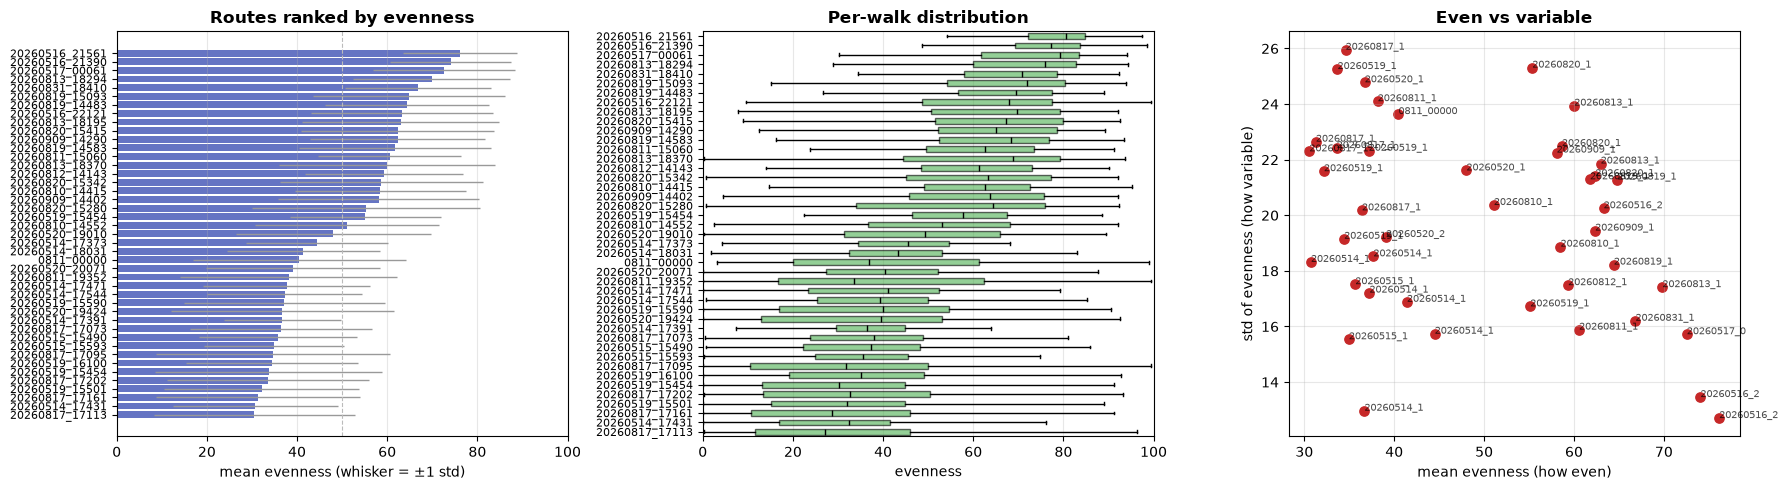

In [12]:
if len(walks):
    # per-walk step distributions, in the same (even-ascending) order as `walks`
    per = {os.path.basename(f): score_recording(f)['evenness'].values
           for f in sorted(glob.glob(WALKS_GLOB, recursive=True))
           if os.path.basename(f) in set(walks['walk'])}
    order = list(walks['walk']); short = [w.replace('REC_','').replace('.csv','')[:14] for w in order]

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    # (1) ranked mean +/- std
    m = walks['mean_evenness'].values; sd = walks['std_evenness'].values
    ax[0].barh(range(len(order)), m, xerr=sd, color='#3F51B5', alpha=.8, error_kw=dict(ecolor='#999', lw=1))
    ax[0].set_yticks(range(len(order))); ax[0].set_yticklabels(short, fontsize=8)
    ax[0].axvline(50, color='#bbb', ls='--', lw=.8); ax[0].set_xlim(0,100)
    ax[0].set_xlabel('mean evenness (whisker = ±1 std)'); ax[0].set_title('Routes ranked by evenness', fontweight='bold'); ax[0].grid(axis='x', alpha=.3)
    # (2) per-walk distributions
    data = [per[w] for w in order]
    bp = ax[1].boxplot(data, vert=False, patch_artist=True, showfliers=False, widths=.6)
    for b in bp['boxes']: b.set_facecolor('#4CAF50'); b.set_alpha(.6)
    for med in bp['medians']: med.set_color('black')
    ax[1].set_yticks(range(1,len(order)+1)); ax[1].set_yticklabels(short, fontsize=8)
    ax[1].set_xlim(0,100); ax[1].set_xlabel('evenness'); ax[1].set_title('Per-walk distribution', fontweight='bold'); ax[1].grid(axis='x', alpha=.3)
    # (3) even vs variable
    ax[2].scatter(walks['mean_evenness'], walks['std_evenness'], s=45, color='#C62828')
    for _,r in walks.iterrows():
        ax[2].annotate(r['walk'].replace('REC_','')[:10], (r['mean_evenness'], r['std_evenness']), fontsize=7, alpha=.7)
    ax[2].set_xlabel('mean evenness (how even)'); ax[2].set_ylabel('std of evenness (how variable)')
    ax[2].set_title('Even vs variable', fontweight='bold'); ax[2].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR,'evenness_by_walk.png'), dpi=140, bbox_inches='tight'); plt.show()
else:
    print('No walks analysed — check WALKS_GLOB.')